In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Machine

```
Machine:    product: Precision 5490  System: Dell Inc.  Type: laptop
System:     Host: is158520  Kernel: 6.17.0-20-generic x86_64  Uptime: 4h 13m
            OS: Ubuntu 25.10  Shell: bash 5.2.37  Desktop: ubuntu:GNOME
CPU:        Model: Intel(R) Core(TM) Ultra 7 165H  Info: 16 cores / 22 threads  Speed: 2080 MHz (min: 400 / max: 4700)
Memory:     RAM: total: 30.04 GiB  used: 8.38 GiB (27.9%)  Swap: total: 8.00 GiB  used: 0 KiB (0.0%)
Graphics:   Card: Intel Corporation Meteor Lake-P [Intel Arc Graphics]  Driver: i915
            Card: NVIDIA Corporation AD107GLM [RTX 2000 Ada Generation Laptop GPU]  Driver: nvidia
Audio:      Card: sof-soundwire  Driver: snd_soc_sof_sdw
            Server: PipeWire  v: 1.4.7  ALSA: k6.17.0-20-generic
```

# "frames" test

3000 cycles of 3-on 3-off frames (phase=100ms) = 5 minutes of stimulation

The Bbtk opto1 is capturing the screen. 

In [7]:
BBTK_FILE="bbtk-capture-004.events.csv"

df = pd.read_csv(BBTK_FILE)
df = df.query("Type == 'Opto1'")

df['DiffOnsets'] = df.Onset.diff()

df.DiffOnsets.describe()


count    2999.000000
mean       99.941814
std         0.260517
min        99.250000
25%        99.750000
50%       100.000000
75%       100.000000
max       100.750000
Name: DiffOnsets, dtype: float64

In [9]:
GOXPY_FILE="Timing-Tests_frames_5min_10Hz.csv"

df2 = pd.read_csv(GOXPY_FILE, comment="#")

df2['period_ms'][1:].describe()


count    2999.000000
mean       99.935005
std         0.296336
min        99.271000
25%        99.748000
50%        99.934000
75%       100.118500
max       100.584000
Name: period_ms, dtype: float64

## is there a correlation between internal (timingtests) and external (bbtk) measurements? 

In [12]:
x = df2['period_ms'][1:]
y = df.DiffOnsets[1:]
np.corrcoef(x,y)

array([[ 1.        , -0.02289994],
       [-0.02289994,  1.        ]])

<Axes: xlabel='period_ms', ylabel='DiffOnsets'>

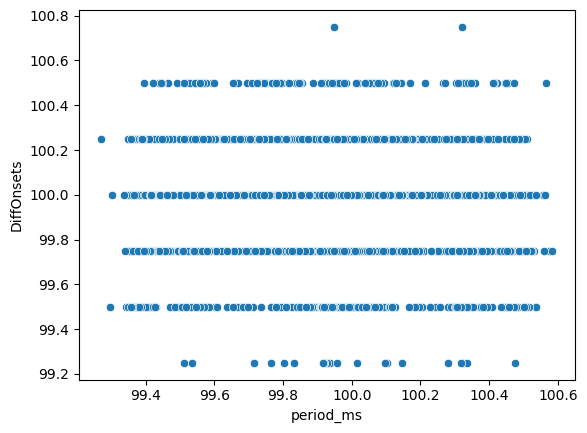

In [14]:
sns.scatterplot(x=x, y=y)

CCL: There is no correlation (which does not really mean much given the tiny intervals), and the bbtk timings are quantized.